In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Fase 1: Simulador Estocástico de Mercado Bursátil ---")

# 1. Configurar el motor matemático de simulación (Random Walk con Tendencia)
np.random.seed(100) 
dias_simulacion = 5 * 252 # 5 años de trading (hay ~252 días laborables de bolsa al año)

# Asumimos que la acción sube de media un 8% al año (tendencia histórica del S&P 500)
# y tiene una volatilidad (riesgo) del 20% anual.
rendimiento_diario_esperado = 0.08 / 252
volatilidad_diaria = 0.20 / np.sqrt(252)

# Generamos los retornos diarios aleatorios siguiendo la campana de Gauss
retornos_diarios = np.random.normal(rendimiento_diario_esperado, volatilidad_diaria, dias_simulacion)

# Convertimos los retornos en precios reales (Empezando en 100$ la acción)
precios = 100 * np.exp(np.cumsum(retornos_diarios))

# Creamos un DataFrame de Pandas (Serie Temporal) simulando fechas reales
fechas = pd.date_range(start='2019-01-01', periods=dias_simulacion, freq='B') # 'B' = Business days
df_mercado = pd.DataFrame({'Precio_Cierre': precios}, index=fechas)

print("✅ 5 años de datos de mercado generados matemáticamente.")

print("\n--- Fase 2: Estrategia del Cruce Dorado (Golden Cross) ---")

# 2. Calculamos las Medias Móviles (SMA - Simple Moving Average)
# Media rápida (Cambiante, capta la tendencia a corto plazo)
df_mercado['SMA_50'] = df_mercado['Precio_Cierre'].rolling(window=50).mean()

# Media lenta (Estable, capta la tendencia a largo plazo)
df_mercado['SMA_200'] = df_mercado['Precio_Cierre'].rolling(window=200).mean()

# 3. Lógica del Robot de Trading (Señales)
# Si la media de 50 días es MAYOR que la de 200, estamos en tendencia alcista firme -> Comprar (1)
# Si es MENOR, se avecina una crisis -> Vender o ponerse Corto (-1)
df_mercado['Senal_Trading'] = np.where(df_mercado['SMA_50'] > df_mercado['SMA_200'], 1, -1)

# Shift(1) es vital: Si hoy calculo la señal, la compra se ejecuta MAÑANA. 
# Esto evita viajar en el tiempo (look-ahead bias), el mayor error de los programadores novatos en trading.
df_mercado['Posicion_Real'] = df_mercado['Senal_Trading'].shift(1)

# Vemos una muestra del final del periodo, donde las medias ya están calculadas
display(df_mercado.tail(10))

--- Fase 1: Simulador Estocástico de Mercado Bursátil ---
✅ 5 años de datos de mercado generados matemáticamente.

--- Fase 2: Estrategia del Cruce Dorado (Golden Cross) ---


,Precio_Cierre,SMA_50,SMA_200,Senal_Trading,Posicion_Real
2023-10-17,152.148726,139.412890,122.398423,1,1.0
2023-10-18,150.604881,139.943051,122.544805,1,1.0
2023-10-19,149.121926,140.477194,122.690123,1,1.0
2023-10-20,149.364530,140.979258,122.825640,1,1.0
2023-10-23,148.869788,141.538727,122.960154,1,1.0
2023-10-24,147.183324,142.067455,123.093796,1,1.0
2023-10-25,148.064883,142.626375,123.237141,1,1.0
2023-10-26,147.077879,143.145642,123.366052,1,1.0
2023-10-27,149.572847,143.740439,123.515795,1,1.0
2023-10-30,148.332034,144.327957,123.663663,1,1.0


--- Fase 3: Motor de Backtesting (Cálculo de Rendimientos) ---
--- Fase 4: Métricas de Riesgo y Visualización ---

📊 --- REPORTE DE RENDIMIENTO (5 AÑOS) ---
📈 Buy & Hold (El Mercado): +51.59%
🤖 Estrategia SMA Crossover: +-36.22%
⚠️ Max Drawdown (Riesgo máximo): -68.39%
⚖️ Sharpe Ratio: -0.33


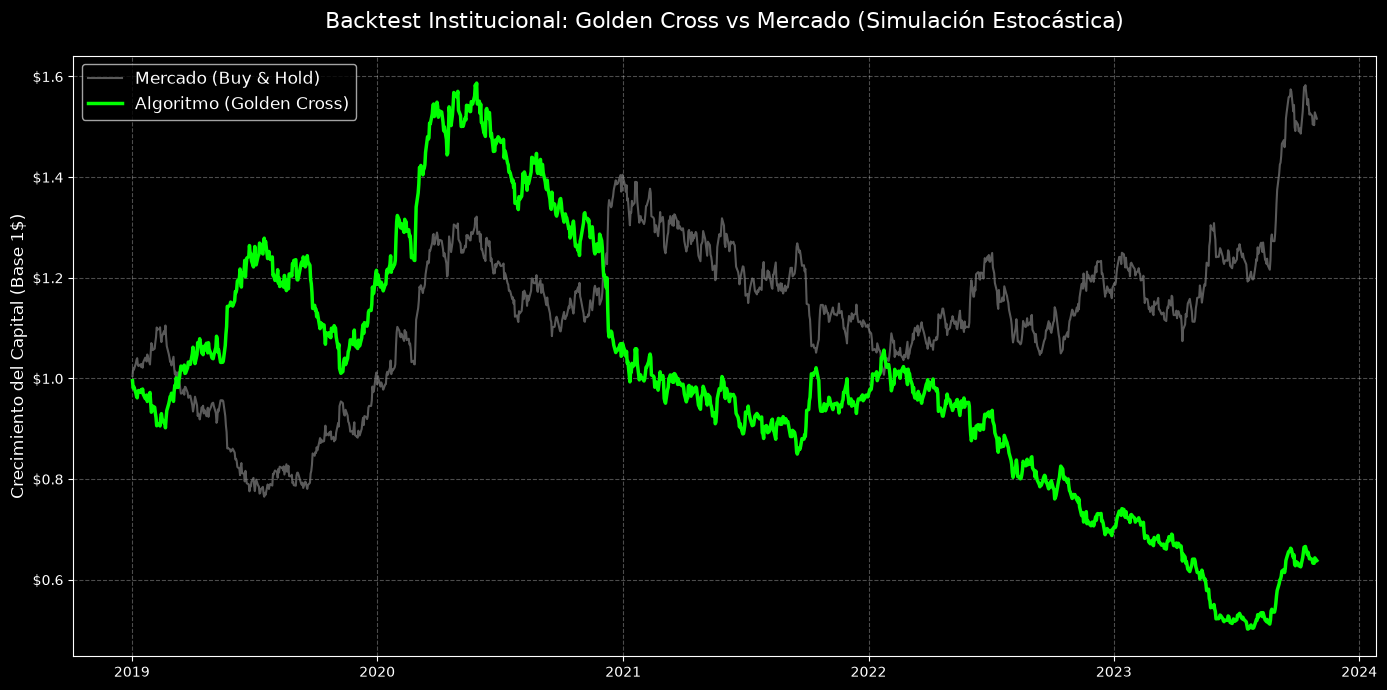

In [2]:
import matplotlib.dates as mdates

print("--- Fase 3: Motor de Backtesting (Cálculo de Rendimientos) ---")

# 1. Retorno diario del mercado (La variación % de un día para otro)
df_mercado['Retorno_Mercado'] = df_mercado['Precio_Cierre'].pct_change()

# 2. Retorno de la Estrategia Cuantitativa
# Ganamos el retorno del mercado SOLO si nuestra señal de ayer era 1 (Comprar). 
# Si era -1 (Vender en corto), ganamos la inversa del mercado.
df_mercado['Retorno_Estrategia'] = df_mercado['Posicion_Real'] * df_mercado['Retorno_Mercado']

# 3. Calculamos la curva de capital acumulada (Empezando con 1$ de inversión)
df_mercado['Equity_Mercado'] = (1 + df_mercado['Retorno_Mercado']).cumprod()
df_mercado['Equity_Estrategia'] = (1 + df_mercado['Retorno_Estrategia']).cumprod()

print("--- Fase 4: Métricas de Riesgo y Visualización ---")

# 4. Cálculo de Métricas Institucionales
# Retorno Total (%)
rendimiento_mercado_pct = (df_mercado['Equity_Mercado'].iloc[-1] - 1) * 100
rendimiento_estrategia_pct = (df_mercado['Equity_Estrategia'].iloc[-1] - 1) * 100

# Max Drawdown de la Estrategia (La peor racha de pérdidas)
pico_historico = df_mercado['Equity_Estrategia'].cummax()
drawdown = (df_mercado['Equity_Estrategia'] - pico_historico) / pico_historico
max_drawdown = drawdown.min() * 100

# Ratio de Sharpe (Asumimos Risk-Free rate = 0% para simplificar)
# Un Sharpe > 1.0 es bueno. > 2.0 es el Santo Grial.
sharpe_ratio = (df_mercado['Retorno_Estrategia'].mean() / df_mercado['Retorno_Estrategia'].std()) * np.sqrt(252)

print("\n📊 --- REPORTE DE RENDIMIENTO (5 AÑOS) ---")
print(f"📈 Buy & Hold (El Mercado): +{rendimiento_mercado_pct:.2f}%")
print(f"🤖 Estrategia SMA Crossover: +{rendimiento_estrategia_pct:.2f}%")
print(f"⚠️ Max Drawdown (Riesgo máximo): {max_drawdown:.2f}%")
print(f"⚖️ Sharpe Ratio: {sharpe_ratio:.2f}")

# 5. Masterpiece Visual (El gráfico para los inversores)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 7))

# Pintamos la evolución de la inversión
ax.plot(df_mercado.index, df_mercado['Equity_Mercado'], label='Mercado (Buy & Hold)', color='#808080', linewidth=1.5, alpha=0.7)
ax.plot(df_mercado.index, df_mercado['Equity_Estrategia'], label='Algoritmo (Golden Cross)', color='#00FF00', linewidth=2.5)

# Formato Institucional
ax.set_title('Backtest Institucional: Golden Cross vs Mercado (Simulación Estocástica)', fontsize=16, pad=20)
ax.set_ylabel('Crecimiento del Capital (Base 1$)', fontsize=12)
ax.yaxis.set_major_formatter('${x:1.1f}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=12, frameon=True)

plt.tight_layout()
plt.show()